# Reconstructing Rasters

Reconstructing rasters means taking a gridded dataset (like a seafloor age grid or paleo-topography map) and using a plate tectonic model to shift it back in time—essentially “undoing” millions of years of plate motion to show how that data looked in the past. This notebook walks you through reconstructing rasters through time!

Let's begin by importing the required packages:

In [1]:
# Ensure you have the required packages installed:
# Run `pip install gplately cartopy matplotlib numpy plate-model-manager` if you haven't already.
import cartopy.crs as ccrs
import gplately
import matplotlib.pyplot as plt
import numpy as np
from plate_model_manager import PlateModelManager

2025-08-12 12:10:43 - gplately - ERROR - Failed to import PyGMT. PyGMT requires Python>=3.11.
2025-08-12 12:10:44 - gplately - ERROR - Failed to import PyGMT. PyGMT requires Python>=3.11.


We begin by loading our plate model and creating `PlateReconstruction` and `PlotTopologies` objects for the [Muller et al. (2019)]("https://agupubs.onlinelibrary.wiley.com/doi/10.1029/2018TC005462) plate tectonic model. Then, we download a raster from EarthByte's webDAV server (for present day i.e. 0 Ma).

> `NOTE:` The 'Unrecognized zip data!' warning message was printed by the plate-model-manager. It is harmless and can be ignored!

In [2]:
pm_manager = PlateModelManager()

# Load the Muller 2019 plate model 
muller2019_model = pm_manager.get_model("Muller2019", data_dir="../../data/plate-model-repo")

# This object will allow us to reconstruct the plate boundaries at different times
model = gplately.PlateReconstruction(
    muller2019_model.get_rotation_model(),
    muller2019_model.get_topologies(),
    muller2019_model.get_static_polygons()
)

# Coastlines, Continental polygons and COBs
coastlines = muller2019_model.get_layer('Coastlines')
continents = muller2019_model.get_layer('ContinentalPolygons')
COBs = muller2019_model.get_layer('COBs')

# Create PlotTopologies object
gplot = gplately.PlotTopologies(model, coastlines=coastlines, continents=continents, COBs=COBs)

# Set time
time = 0  # Ma

# Download and create a global raster for age grids at 0 Ma
muller_2019_age_grid = gplately.Raster(
    data=muller2019_model.get_raster("AgeGrids", time),
    plate_reconstruction=model,
    extent=[-180, 180, -90, 90],  # Defines the geographical boundaries of the raster grid (entire globe in this case)
)

The `muller_2019_age_grid` raster can be reconstructed back in time by assigning a `plate_reconstruction` to the object. We use the plate reconstruction we defined earlier (`model`). Note that a Raster object will also accept a `plate_reconstruction` at initialisation.

After this, we use `reconstruct` to reconstruct the raster to a given time (in this case, 25 Ma).

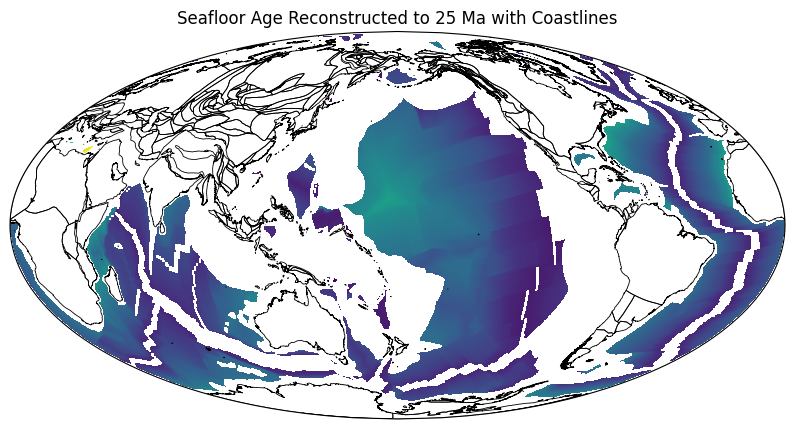

In [3]:
# Assign a plate reconstruction in order to reconstruct the raster
muller_2019_age_grid.plate_reconstruction = model

# Time = 25 Ma
muller_2019_age_grid_reconstructed = muller_2019_age_grid.reconstruct(25, threads=4, fill_value=np.nan)

# Create the plot
fig = plt.figure(figsize=(10, 6))
ax1 = fig.add_subplot(111, projection=ccrs.Mollweide(central_longitude=180))

# Plot the reconstructed raster
muller_2019_age_grid_reconstructed.imshow(ax1)

# Plot coastlines on top for context
gplot.time = 25  # Set the plot time so coastlines are reconstructed to 25 Ma
gplot.plot_coastlines(ax1, edgecolor='k', linewidth=0.6)

# Show the plot
plt.title("Seafloor Age Reconstructed to 25 Ma with Coastlines")
plt.show()


Rasters can be also be reverse reconstructed forward in time!

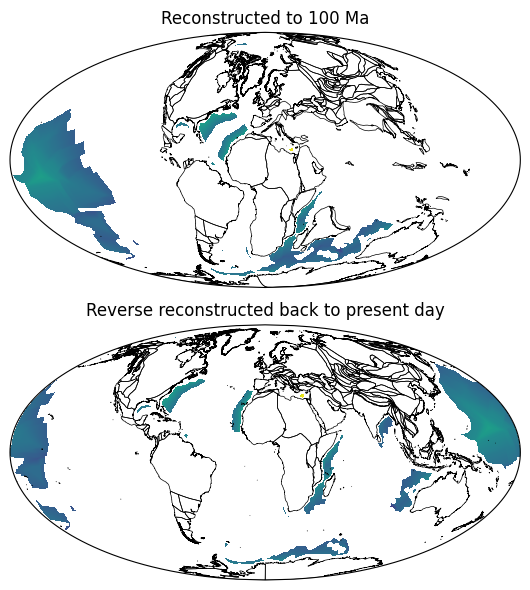

In [4]:
# Time = 100 Ma
reconstructed = muller_2019_age_grid.reconstruct(100, fill_value=np.nan, threads=4)

# Time = 0 Ma (reverse reconstruction)
reverse_reconstructed = reconstructed.reconstruct(0, fill_value=np.nan, threads=4)

# Set time for plotting
gplot.time = 100  # Used for reconstructed plot

# Create subplots
fig, axs = plt.subplots(2, 1, figsize=(10, 6), subplot_kw={"projection": ccrs.Mollweide(central_longitude=0)})

# Plot raster reconstructed to 100 Ma
reconstructed.imshow(ax=axs[0])
gplot.plot_coastlines(axs[0], edgecolor='k', linewidth=0.5)  # Add coastlines
axs[0].set_title("Reconstructed to 100 Ma")

# Plot raster reverse-reconstructed to 0 Ma
gplot.time = 0
reverse_reconstructed.imshow(ax=axs[1])
gplot.plot_coastlines(axs[1], edgecolor='k', linewidth=0.5)  # Add coastlines
axs[1].set_title("Reverse reconstructed back to present day")

plt.tight_layout()
plt.show()